**Conjunto de datos**: En este ejemplo de regresión polinómica, en lugar de usar un dataset existente generaremos nuestro propio conjunto de puntos de datos de forma aleatoria. Comenzamos generando datos no lineales aleatorios, combinando el uso de una ecuación cuadrática con algo de ruido gaussiano introducido al azar, de modo que la nube de puntos se asemeje - pero no sea exactamente igual a - la curva de una función cuadrática:
$$\textbf{y} = 0.5\textbf{x}^2 + \textbf{x} + 2 + rand(0,1)$$

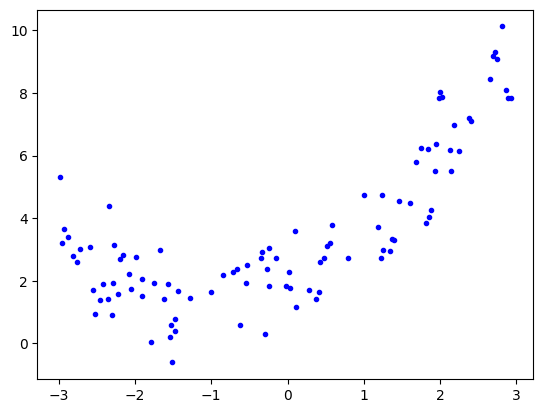

In [1]:
import numpy as np
import matplotlib.pyplot as plt

m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m,1)

plt.plot(X, y, "b.")

Como podemos observar en el gráfico anterior, debido al papel de la ecuación cuadrática en el proceso de generación de datos, la nube de puntos de datos se asemeja ligeramente a una función cuadrática o parabólica. Esto nos da una pista de que un **modelo de regresión polinómica de grado 2** sería una buena opción para intentar ajustarnos a estos datos.

La clase **PolynomialFeatures** de *scikit-learn* ayuda a transformar los datos de entrenamiento, añadiendo nuevas características que consisten en potencias de los atributos numéricos originales. Es un modo de disfrazar datos que no son lineales, en datos lineales, y de este modo poder usar un modelo de regresión lineal aunque en realidad se trate de regresión polinomial.

En este ejemplo, solo tenemos un atributo y optaremos por añadir un nuevo atributo como el cuadrado (polinomio de grado 2) de los valores originales:

In [2]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0], X_poly[0]

(array([2.3848622]), array([2.3848622 , 5.68756773]))

Ahora podemos simular un proceso de regresión "linear" sobre el dataset aumentado:

In [3]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.98621688]), array([[1.03317178, 0.49022808]]))

Entrenemos también una línea de regresión con el conjunto de datos original (es decir, una regresión verdaderamente lineal, sin el nuevo atributo cuadrado) y compararemos gráficamente los dos modelos entrenados:

In [4]:
lin_reg1 = LinearRegression()
lin_reg1.fit(X, y) # WARNING: here are using the original, not extended data for training
lin_reg1.intercept_, lin_reg1.coef_

(array([3.61934248]), array([[0.96780753]]))

(np.float64(-3.0), np.float64(3.0), np.float64(0.0), np.float64(10.0))

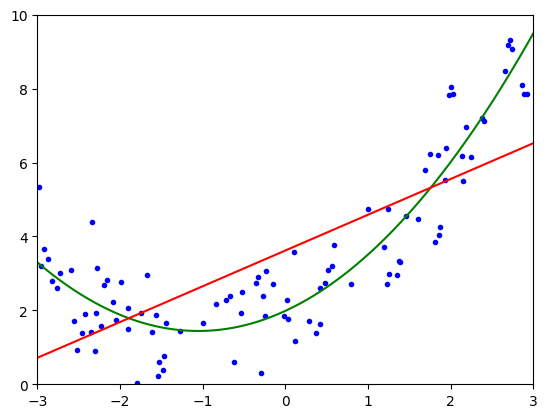

In [5]:
# Plot the data
plt.plot(X, y, "b.")

x = np.linspace(-3, 3, 1000) # 1000 points evenly separated along the interval [-3,3]

# Plot the polynomial regression curve (parabola)
yq = lin_reg.coef_[0][0]*x + lin_reg.coef_[0][1]*(x**2) + lin_reg.intercept_[0]
plt.plot(x, yq, "g-")

# Plot the simple linear regression line learnt
yl = lin_reg1.coef_[0]*x + lin_reg1.intercept_[0]
plt.plot(x, yl, "r-")

plt.axis([-3, 3, 0, 10])

**Actividad propuesta**
Entrenar un modelo de regresión polinómica de grado 3 siguiendo los mismos pasos que antes:

1. Utilizar la clase **Polynomialfeatures** para obtener una versión aumentada adecuada del conjunto de datos con atributos adicionales de hasta grado 3.
2. Crear y entrenar el nuevo modelo utilizando la clase **LinearRegression** en el nuevo conjunto de datos aumentado.
3. Visualizar y comparar los resultados de este modelo con el primero, calculando el error cometido.

In [6]:
poly_features_3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly_3 = poly_features_3.fit_transform(X)
X[0], X_poly_3[0]

(array([2.3848622]), array([ 2.3848622 ,  5.68756773, 13.5640653 ]))

In [7]:
lin_reg_3 = LinearRegression()
lin_reg_3.fit(X_poly_3, y)
lin_reg_3.intercept_, lin_reg_3.coef_

(array([1.98748563]), array([[ 1.10283777,  0.48914373, -0.01261894]]))

Podemos observar que el último coeficiente o peso, asociado a **$x^3$**, es bastante pequeño, alrededor de 0,000317, en comparación con los coeficientes de $x^2$ y $x$. Estos dos son casi idénticos a los obtenidos previamente por el primer modelo de regresión (grado 2) que entrenamos. Por lo tanto, este modelo se parece mucho al anterior.

Esto no debe sorprendernos: recuerda que originalmente generamos de forma intencionada puntos de datos que se asemejasen bastante a una función cuadrática, por lo que la visualización de este nuevo modelo no debería ser muy diferente de una función cuadrática, a pesar de ser un polinomio de grado 3. En otras palabras, no solo no es necesario aumentar la complejidad del modelo, sino que hacerlo al extremo podría dar lugar a un modelo problemático debido, por ejemplo, al sobreajuste.

(np.float64(-3.0), np.float64(3.0), np.float64(0.0), np.float64(10.0))

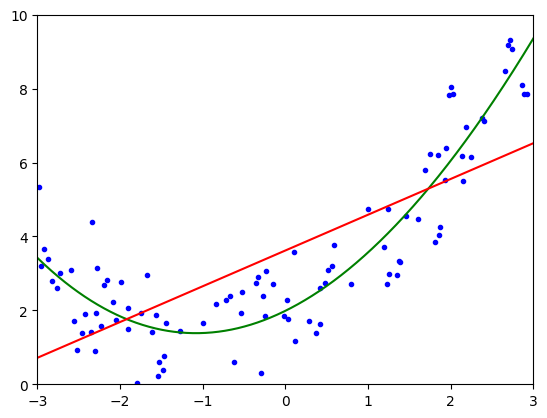

In [8]:
# Plot the data
plt.plot(X, y, "b.")

x = np.linspace(-3, 3, 1000) # 1000 points evenly separated along the interval [-3,3]

# Plot the polynomial regression curve (parabola)
yq3 = lin_reg_3.coef_[0][0]*x + lin_reg_3.coef_[0][1]*(x**2) + lin_reg_3.coef_[0][2]*(x**3) + lin_reg_3.intercept_[0]
plt.plot(x, yq3, "g-")

# Plot the simple linear regression line learnt
yl = lin_reg1.coef_[0]*x + lin_reg1.intercept_[0]
plt.plot(x, yl, "r-")

plt.axis([-3, 3, 0, 10])